# Mental Health Darija — Model comparison

Compare **TF-IDF + Logistic Regression (baseline)** and **Hugging Face models** on the same test set. Uses the Mental Health Darija dataset with a fixed 90/10 train–test split.

## 1. Load data and split

In [22]:
from datasets import load_dataset

full = load_dataset("moujar/MentalHealth-Darija")["train"]
dataset = full.train_test_split(test_size=0.1, seed=1337)
dataset

DatasetDict({
    train: Dataset({
        features: ['text_en', 'text', 'label'],
        num_rows: 45983
    })
    test: Dataset({
        features: ['text_en', 'text', 'label'],
        num_rows: 5110
    })
})

In [23]:
# Convert to plain list of str so pipeline(text-classification) accepts them
train_texts = [str(t) for t in dataset["train"]["text"]]
train_labels = list(dataset["train"]["label"])
test_texts = [str(t) for t in dataset["test"]["text"]]
y_true = list(dataset["test"]["label"])

label2id = {'Anxiety': 0, 'Normal': 1, 'Depression': 2, 'Suicidal': 3, 'Stress': 4, 'Bipolar': 5, 'Personality disorder': 6}

print(f"Train: {len(train_texts)}, Test: {len(y_true)}")

Train: 45983, Test: 5110


In [38]:
from pprint import pprint

# Show first examples of test_text using pretty printing
id2label = {v: k for k, v in label2id.items()}
samples = []
for i in range(5):
    sample = {
        "Sample": i + 1,
        "Text": test_texts[i],
        "Label id": y_true[i],
        "Label name": id2label[y_true[i]]
    }
    samples.append(sample)
pprint(samples, sort_dicts=False, width=100)

[{'Sample': 1,
  'Text': '@darkmagique O آه أنا متأكد! أنا فرحان بزاف بلي شافها AgaiN... شنو الوقت؟..Onish? '
          'Jaaaaaah ! lolm !',
  'Label id': 1,
  'Label name': 'Normal'},
 {'Sample': 2,
  'Text': 'أنا تبرعت بالدم اليوم. ما عرفتش، كيحسني مزيان باش نقدر نعاون شي واحد آخر فهاد الجسم لي '
          'كنكره. زيد على هادشي، خرج شوية ديال الدم ملي دخلات الإبرة، وملي شفت هاد الدم حسيت براسي '
          'مزيان. تبرعت بالدم اليوم',
  'Label id': 2,
  'Label name': 'Depression'},
 {'Sample': 3,
  'Text': 'واش كاين شي واحد كيحس براسو خايب وممنوع ملي الناس كيقولو بلي لاحظو بلي الاكتئاب ديالك '
          'تحسن، ولكن فالحقيقة غير حبستي تكشف وتعاني بوحدك حيت ملي بانو ليك الأعراض تقلقو وتعيا من '
          'التعامل معاها. واش أنا كنحسن إلا عوض ما نبكي ولا عندي التنميل؟ إلا عطاوني فرصة باش ندمر '
          'راسي بلا ما نأذي حد وعندي عواقب خايبة غادي نديرها فثانية. كيقولو بلي الاكتئاب ديالي '
          'كيتحسن؟',
  'Label id': 2,
  'Label name': 'Depression'},
 {'Sample': 4,
  'Text': 'كيعجب

## 2. Baseline: TF-IDF + Logistic Regression

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

vectorizer = TfidfVectorizer(max_features=20_000, ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(train_texts)
X_test_tfidf = vectorizer.transform(test_texts)

clf = LogisticRegression(max_iter=500, random_state=42, multi_class="multinomial", solver="lbfgs", C=1.0)
clf.fit(X_train_tfidf, train_labels)
y_pred_baseline = clf.predict(X_test_tfidf)

results = [{
    "model": "TF-IDF + Logistic Regression (baseline)",
    "accuracy": accuracy_score(y_true, y_pred_baseline),
    "f1_weighted": f1_score(y_true, y_pred_baseline, average="weighted"),
    "error": None,
}]
print(f"Baseline — Accuracy: {results[0]['accuracy']:.4f}, F1: {results[0]['f1_weighted']:.4f}")

/home/agi/.local/share/mamba/envs/ai/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Baseline — Accuracy: 0.6953, F1: 0.6845


## 3. Hugging Face models

In [25]:
# Models that load with AutoModelForSequenceClassification
HF_MODELS = [
    "oelbourki/MARBERT_classification_mental_darija",
    "oelbourki/Modern_bert_classification_mental_darija",
]

In [27]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from tqdm.auto import tqdm
import torch

def evaluate_model(model_id, test_texts, y_true, batch_size=32, device=None):
    """Use AutoModelForSequenceClassification so we get class indices 0..num_labels-1."""
    if device is None:
        device = 0 if torch.cuda.is_available() else -1
    try:
        tokenizer = AutoTokenizer.from_pretrained(model_id)
        model = AutoModelForSequenceClassification.from_pretrained(model_id)
        if device >= 0:
            model = model.to(f"cuda:{device}")
    except Exception as e:
        return {"model": model_id, "accuracy": None, "f1_weighted": None, "error": str(e)[:200]}

    num_labels = getattr(model.config, "num_labels", None)
    if num_labels is None or num_labels != 7:
        return {"model": model_id, "accuracy": None, "f1_weighted": None, "error": f"num_labels={num_labels}"}

    model.eval()
    pred_labels = []
    for i in tqdm(range(0, len(test_texts), batch_size), leave=False, desc=model_id.split("/")[-1]):
        batch = test_texts[i : i + batch_size]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=512, return_tensors="pt")
        if device >= 0:
            enc = {k: v.to(model.device) for k, v in enc.items()}
        with torch.no_grad():
            out = model(**enc)
        pred_labels.extend(out.logits.argmax(dim=-1).cpu().tolist())
    pred_labels = [int(p) for p in pred_labels]
    return {
        "model": model_id,
        "accuracy": accuracy_score(y_true, pred_labels),
        "f1_weighted": f1_score(y_true, pred_labels, average="weighted"),
        "error": None,
    }

for model_id in tqdm(HF_MODELS, desc="Evaluating models"):
    results.append(evaluate_model(model_id, test_texts, y_true))

Evaluating models:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating models: 100%|██████████| 2/2 [03:02<00:00, 91.26s/it] 


## 4. Results table

In [28]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df["model_short"] = results_df["model"].str.replace("oelbourki/", "", regex=False)
results_df[["model_short", "accuracy", "f1_weighted", "error"]]

,model_short,accuracy,f1_weighted,error
0,TF-IDF + Logistic Regression (baseline),0.695303,0.684451,None
1,MARBERT_classification_mental_darija,0.770450,0.771271,None
2,Modern_bert_classification_mental_darija,0.663796,0.645946,None


## 5. Charts

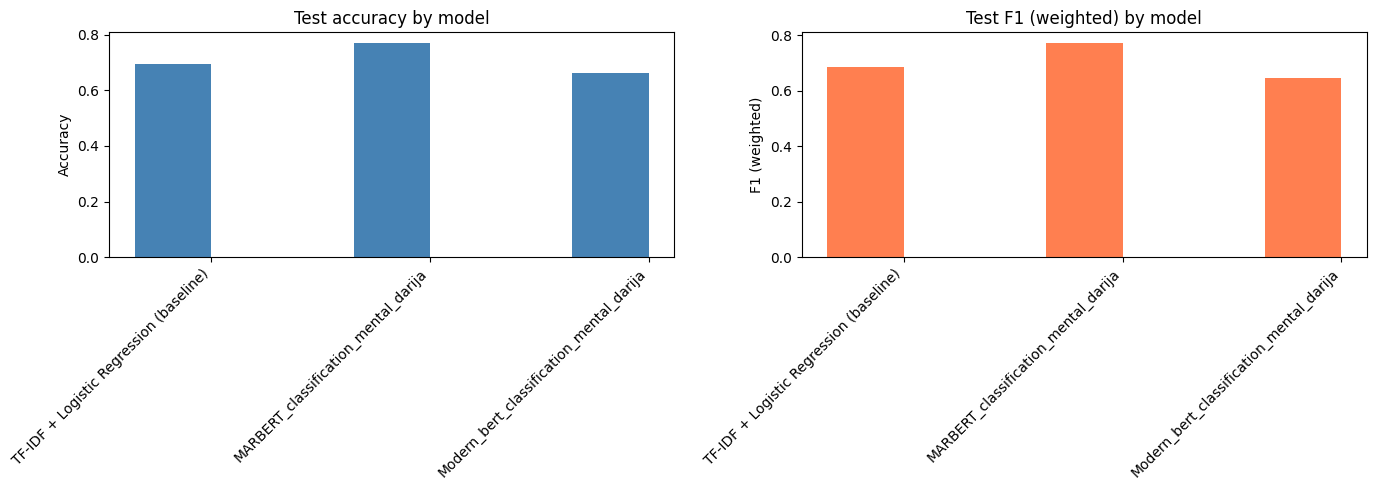

In [29]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = results_df.dropna(subset=["accuracy", "f1_weighted"])
if plot_df.empty:
    print("No valid metrics to plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(plot_df))
    w = 0.35
    axes[0].bar(x - w/2, plot_df["accuracy"], width=w, color="steelblue")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(plot_df["model_short"], rotation=45, ha="right")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title("Test accuracy by model")
    axes[1].bar(x - w/2, plot_df["f1_weighted"], width=w, color="coral")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(plot_df["model_short"], rotation=45, ha="right")
    axes[1].set_ylabel("F1 (weighted)")
    axes[1].set_title("Test F1 (weighted) by model")
    plt.tight_layout()
    plt.show()

## 6. LLMs (Atlas / Qwen2-based) with Unsloth

Load model and tokenizer using **Unsloth** `FastModel.from_pretrained` (same as the BERT classification notebook). Adapter repos are loaded as base + adapter automatically.

In [30]:
MODELS = [
    "oelbourki/atlasia-Al-Atlas-0.5B_64_3_classification_mental_darija",
    "oelbourki/atlasia-Al-Atlas-0.5B_128_classification_mental_darija",
    "oelbourki/atlasia-Al-Atlas-0.5B_classification_mental_darija",
]

import os
os.environ["UNSLOTH_DISABLE_FAST_GENERATION"] = "1"  # for BERT-style / classification
from unsloth import FastModel
from transformers import AutoModelForSequenceClassification

id2label = {0: 'Anxiety', 1: 'Normal', 2: 'Depression', 3: 'Suicidal', 4: 'Stress', 5: 'Bipolar', 6: 'Personality disorder'}
label2id = {'Anxiety': 0, 'Normal': 1, 'Depression': 2, 'Suicidal': 3, 'Stress': 4, 'Bipolar': 5, 'Personality disorder': 6}

results_unsloth = []  # keep separate from main results_df
batch_size = 32
max_seq_length = 512

for model_id in tqdm(MODELS, desc="Trying failed models (Unsloth)"):
    try:
        model, tokenizer = FastModel.from_pretrained(
            model_name=model_id,
            auto_model=AutoModelForSequenceClassification,
            max_seq_length=max_seq_length,
            dtype=None,
            num_labels=7,
            id2label=id2label,
            label2id=label2id,
            load_in_4bit=True,
            device_map="balanced",
        )
        model.eval()
        pred_labels = []
        for i in range(0, len(test_texts), batch_size):
            batch = test_texts[i : i + batch_size]
            enc = tokenizer(batch, padding=True, truncation=True, max_length=max_seq_length, return_tensors="pt")
            enc = {k: v.to(model.device) for k, v in enc.items()}
            with torch.no_grad():
                out = model(**enc)
            pred_labels.extend(out.logits.argmax(dim=-1).cpu().tolist())
        pred_labels = [int(p) for p in pred_labels]
        results_unsloth.append({
            "model": model_id,
            "accuracy": accuracy_score(y_true, pred_labels),
            "f1_weighted": f1_score(y_true, pred_labels, average="weighted"),
            "error": None,
        })
        del model
        torch.cuda.empty_cache()
    except Exception as e:
        results_unsloth.append({"model": model_id, "accuracy": None, "f1_weighted": None, "error": str(e)[:200]})

results_unsloth_df = pd.DataFrame(results_unsloth)
results_unsloth_df

Trying failed models (Unsloth):   0%|          | 0/3 [00:00<?, ?it/s]

==((====))==  Unsloth 2026.2.1: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 4080 Laptop GPU. Num GPUs = 1. Max memory: 11.994 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at atlasia/Al-Atlas-0.5B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


atlasia/Al-Atlas-0.5B does not have a padding token! Will use pad_token = <|vision_pad|>.
Unsloth: Allowing gradients for `base_model.model.score` since it's in `modules_to_save`.


Trying failed models (Unsloth):  33%|███▎      | 1/3 [00:45<01:31, 45.92s/it]

...

==((====))==  Unsloth 2026.2.1: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 4080 Laptop GPU. Num GPUs = 1. Max memory: 11.994 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Some weights of Qwen2ForSequenceClassification were not initialized from the model checkpoint at atlasia/Al-Atlas-0.5B and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


atlasia/Al-Atlas-0.5B does not have a padding token! Will use pad_token = <|vision_pad|>.
Unsloth: Allowing gradients for `base_model.model.score` since it's in `modules_to_save`.


Trying failed models (Unsloth): 100%|██████████| 3/3 [02:42<00:00, 54.16s/it]


,model,accuracy,f1_weighted,error
0,oelbourki/atlasia-Al-Atlas-0.5B_64_3_classific...,0.779843,0.778422,None
1,oelbourki/atlasia-Al-Atlas-0.5B_128_classifica...,0.736791,0.728699,None
2,oelbourki/atlasia-Al-Atlas-0.5B_classification...,0.768885,0.766535,None


## 7. Combined results (all models)

After both the main models and the Unsloth (Atlas) models have been evaluated, combine everything into one table and one set of charts.

In [31]:
# Merge main results (results_df) and Unsloth results (results_unsloth_df) into one dataframe
combined_df = pd.concat([results_df, results_unsloth_df], ignore_index=True)
combined_df["model_short"] = combined_df["model"].str.replace("oelbourki/", "", regex=False)
combined_df[["model_short", "accuracy", "f1_weighted", "error"]]

,model_short,accuracy,f1_weighted,error
0,TF-IDF + Logistic Regression (baseline),0.695303,0.684451,None
1,MARBERT_classification_mental_darija,0.770450,0.771271,None
2,Modern_bert_classification_mental_darija,0.663796,0.645946,None
3,atlasia-Al-Atlas-0.5B_64_3_classification_ment...,0.779843,0.778422,None
4,atlasia-Al-Atlas-0.5B_128_classification_menta...,0.736791,0.728699,None
5,atlasia-Al-Atlas-0.5B_classification_mental_da...,0.768885,0.766535,None


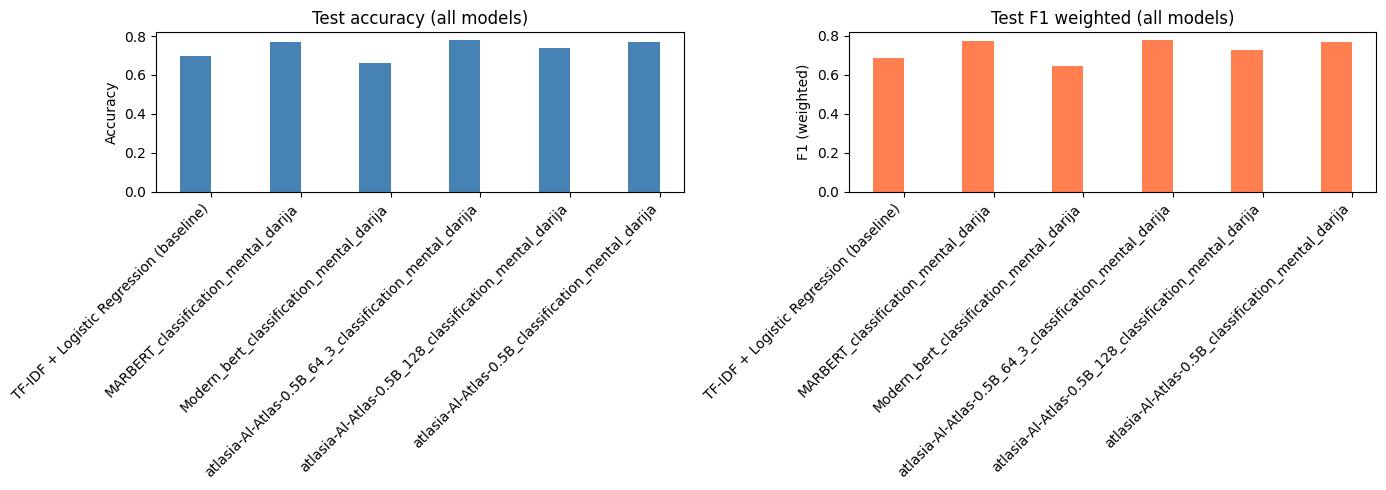

In [32]:
# Charts for all models that have valid metrics
plot_all = combined_df.dropna(subset=["accuracy", "f1_weighted"])
if plot_all.empty:
    print("No valid metrics to plot.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    x = np.arange(len(plot_all))
    w = 0.35
    axes[0].bar(x - w/2, plot_all["accuracy"], width=w, color="steelblue")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(plot_all["model_short"], rotation=45, ha="right")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_title("Test accuracy (all models)")
    axes[1].bar(x - w/2, plot_all["f1_weighted"], width=w, color="coral")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(plot_all["model_short"], rotation=45, ha="right")
    axes[1].set_ylabel("F1 (weighted)")
    axes[1].set_title("Test F1 weighted (all models)")
    plt.tight_layout()
    plt.show()

In [33]:
# Summary: all models ranked by F1
summary_all = plot_all[["model_short", "accuracy", "f1_weighted"]].sort_values("f1_weighted", ascending=False)
summary_all["accuracy"] = summary_all["accuracy"].apply(lambda x: f"{x:.2%}")
summary_all["f1_weighted"] = summary_all["f1_weighted"].apply(lambda x: f"{x:.2%}")
summary_all

,model_short,accuracy,f1_weighted
3,atlasia-Al-Atlas-0.5B_64_3_classification_ment...,77.98%,77.84%
1,MARBERT_classification_mental_darija,77.05%,77.13%
5,atlasia-Al-Atlas-0.5B_classification_mental_da...,76.89%,76.65%
4,atlasia-Al-Atlas-0.5B_128_classification_menta...,73.68%,72.87%
0,TF-IDF + Logistic Regression (baseline),69.53%,68.45%
2,Modern_bert_classification_mental_darija,66.38%,64.59%


In [34]:
# Summary: ranked by F1
summary = plot_df[["model_short", "accuracy", "f1_weighted"]].sort_values("f1_weighted", ascending=False)
summary["accuracy"] = summary["accuracy"].apply(lambda x: f"{x:.2%}")
summary["f1_weighted"] = summary["f1_weighted"].apply(lambda x: f"{x:.2%}")
summary

,model_short,accuracy,f1_weighted
1,MARBERT_classification_mental_darija,77.05%,77.13%
0,TF-IDF + Logistic Regression (baseline),69.53%,68.45%
2,Modern_bert_classification_mental_darija,66.38%,64.59%
